# 02 Annotation Reference Velocity

## 1. Purpose and Method

This notebook builds and validates an annotation-derived reference velocity workflow for tracked objects in TruckScenes.

The reference motion is derived from object annotation trajectories rather than directly from RADAR, LiDAR, or ego-motion measurements.

Object annotations are linked across frames using `instance_token`. The `prev` and `next` fields in `sample_annotation.json` are also inspected to verify that annotations form reasonable object trajectories.

Each annotation is linked to its corresponding sample timestamp through:

`sample_annotation.sample_token` → `sample.token` → `sample.timestamp`

TruckScenes `sample.timestamp` values are stored in microseconds (µs) and represent annotation keyframe times.

For two consecutive annotations of the same object, the raw timestamp difference is:

$$
\Delta t_{\mu s} = t_2 - t_1
$$

The timestamp difference in seconds is then:

$$
\Delta t_s = \frac{\Delta t_{\mu s}}{1{,}000{,}000}
$$

The position changes are:

$$
\Delta x = x_2 - x_1
$$

$$
\Delta y = y_2 - y_1
$$

$$
\Delta z = z_2 - z_1
$$

The primary displacement measure is the 2D ground-plane displacement:

$$
d_{2D} = \sqrt{(\Delta x)^2 + (\Delta y)^2}
$$

A 3D displacement is also calculated for diagnostic comparison:

$$
d_{3D} = \sqrt{(\Delta x)^2 + (\Delta y)^2 + (\Delta z)^2}
$$

Once the unit of annotation translation has been confirmed, the 2D reference velocity can be calculated as:

$$
v_{2D} = \frac{d_{2D}}{\Delta t_s}
$$

The 2D ground-plane velocity is used as the primary vehicle reference because road vehicles mainly move in the horizontal plane. Vertical motion is retained for diagnostic purposes because changes in the annotation `z` coordinate may increase the apparent 3D velocity.

This notebook first constructs trajectories for all annotated object instances. Object-category metadata is inspected separately before defining which categories should be treated as vehicles.

The workflow checks for:

- missing required metadata fields;
- missing sample timestamps;
- object instances with only one annotation;
- inconsistent annotation `prev` and `next` relationships;
- duplicate timestamps within an instance;
- non-positive timestamp differences;
- unusual position changes;
- unusual derived velocities.

Potentially invalid or unusual records are reported before any filtering is applied.

This notebook only establishes and validates the annotation-derived reference velocity. RADAR velocity analysis, LiDAR motion analysis, sensor-information efficiency analysis, and RADAR–LiDAR comparison are performed in later notebooks.

## 2. Load and Validate Annotation Metadata

The annotation trajectory workflow requires metadata from `sample.json`, `sample_annotation.json`, and `instance.json`.

`category.json` is also loaded when available so that vehicle categories can be examined later.

Before constructing trajectories, the required files, JSON structures, and actual metadata fields are validated.

The main metadata relationships required by this notebook are:

- `sample_annotation.sample_token` → `sample.token`
- `sample_annotation.instance_token` → `instance.token`
- `instance.category_token` → `category.token`

No object-category filtering is applied at this stage.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Locate the project root
PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(
        "Could not locate the project root containing the src/ directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# Project configuration and data loading
from src.config import METADATA_ROOT
from src.data_io import load_json

# Annotation reference-velocity workflow
from src.annotation_velocity import (
    build_annotation_trajectory_df,
    build_annotation_pairs,
    add_time_differences,
    add_position_changes,
    add_reference_velocity,
)

In [2]:
from pathlib import Path
import sys

# Locate the project root.
# This notebook is normally stored inside the notebook/ directory.
PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(
        "Could not locate the project root containing the src/ directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
import pandas as pd

from src.config import METADATA_ROOT
from src.data_io import load_json


metadata_paths = {
    "sample.json": METADATA_ROOT / "sample.json",
    "sample_annotation.json": METADATA_ROOT / "sample_annotation.json",
    "instance.json": METADATA_ROOT / "instance.json",
    "category.json": METADATA_ROOT / "category.json",
}


required_files = [
    "sample.json",
    "sample_annotation.json",
    "instance.json",
]


missing_files = [
    filename
    for filename in required_files
    if not metadata_paths[filename].exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required metadata files are missing: "
        + ", ".join(missing_files)
    )


samples = load_json(
    metadata_paths["sample.json"]
)

annotations = load_json(
    metadata_paths["sample_annotation.json"]
)

instances = load_json(
    metadata_paths["instance.json"]
)

categories = (
    load_json(metadata_paths["category.json"])
    if metadata_paths["category.json"].exists()
    else None
)


metadata_tables = {
    "sample.json": samples,
    "sample_annotation.json": annotations,
    "instance.json": instances,
}

if categories is not None:
    metadata_tables["category.json"] = categories


for filename, records in metadata_tables.items():

    if not isinstance(records, list):
        raise ValueError(
            f"{filename} is expected to contain a list of records."
        )

    if not records:
        raise ValueError(
            f"{filename} contains no records."
        )

    if not all(isinstance(record, dict) for record in records):
        raise ValueError(
            f"{filename} contains one or more non-dictionary records."
        )


structure_records = []

for filename, records in metadata_tables.items():

    all_fields = sorted(
        set().union(
            *(record.keys() for record in records)
        )
    )

    common_fields = sorted(
        set.intersection(
            *(set(record.keys()) for record in records)
        )
    )

    structure_records.append({
        "Metadata_File": filename,
        "Records": len(records),
        "Fields": ", ".join(all_fields),
        "Fields_in_All_Records": ", ".join(common_fields),
        "Consistent_Structure": (
            set(all_fields) == set(common_fields)
        ),
    })


metadata_structure = pd.DataFrame(
    structure_records
)

if categories is None:
    print("category.json was not found.")

display(metadata_structure)

,Metadata_File,Records,Fields,Fields_in_All_Records,Consistent_Structure
0,sample.json,400,"ego_motion_cabin_token, ego_motion_chassis_tok...","ego_motion_cabin_token, ego_motion_chassis_tok...",True
1,sample_annotation.json,25750,"attribute_tokens, instance_token, next, num_li...","attribute_tokens, instance_token, next, num_li...",True
2,instance.json,1094,"category_token, first_annotation_token, last_a...","category_token, first_annotation_token, last_a...",True
3,category.json,27,"description, index, name, token","description, index, name, token",True


In [4]:
# Required fields for the annotation trajectory workflow
required_fields = {
    "sample.json": {
        "token",
        "timestamp",
    },
    "sample_annotation.json": {
        "token",
        "sample_token",
        "instance_token",
        "translation",
        "prev",
        "next",
    },
    "instance.json": {
        "token",
        "category_token",
        "nbr_annotations",
        "first_annotation_token",
        "last_annotation_token",
    },
    "category.json": {
        "token",
        "name",
    },
}


for filename, fields in required_fields.items():

    records = metadata_tables.get(filename)

    if records is None:
        raise ValueError(
            f"{filename} is required for this step but was not loaded."
        )

    actual_fields = set(
        records[0].keys()
    )

    missing_fields = fields - actual_fields

    if missing_fields:
        raise ValueError(
            f"{filename} is missing required fields: "
            + ", ".join(sorted(missing_fields))
        )


print("Required fields: OK")


# Check annotation links
sample_tokens = {
    record["token"]
    for record in samples
}

instance_tokens = {
    record["token"]
    for record in instances
}


missing_sample_links = sum(
    annotation["sample_token"] not in sample_tokens
    for annotation in annotations
)

missing_instance_links = sum(
    annotation["instance_token"] not in instance_tokens
    for annotation in annotations
)


# Check translation structure
invalid_translations = sum(
    not isinstance(annotation["translation"], (list, tuple))
    or len(annotation["translation"]) != 3
    for annotation in annotations
)


print("Missing sample links:", missing_sample_links)
print("Missing instance links:", missing_instance_links)
print("Invalid translation records:", invalid_translations)


# Display actual object categories
category_df = (
    pd.DataFrame(categories)
    [["index", "name", "description"]]
    .sort_values("index")
    .reset_index(drop=True)
)

display(category_df)

Required fields: OK
Missing sample links: 0
Missing instance links: 0
Invalid translation records: 0


,index,name,description
0,1,vehicle.car,"Vehicle designed primarily for personal use, e..."
1,2,vehicle.truck,Vehicles primarily designed to haul cargo incl...
2,3,vehicle.bus.bendy,Buses and shuttles designed to carry more than...
3,4,vehicle.bus.rigid,Rigid buses and shuttles designed to carry mor...
4,5,vehicle.construction,Vehicles primarily designed for construction. ...
5,6,vehicle.motorcycle,Gasoline or electric powered 2-wheeled vehicle...
6,7,static_object.bicycle_rack,Area or device intended to park or secure the ...
7,8,vehicle.bicycle,Human or electric powered 2-wheeled vehicle de...
8,9,vehicle.trailer,"Any vehicle trailer, both for trucks, cars and..."
9,10,vehicle.emergency.police,All types of police vehicles including police ...


## 3. Inspect Annotation Trajectories

A trajectory table is constructed by linking each annotation to its sample timestamp and object category.

Each row in `trajectory_df` represents one annotated object instance at one annotation keyframe.

Before constructing consecutive annotation pairs, the trajectory table is checked for missing timestamps, single-annotation instances, and consistency with the annotation counts reported in `instance.json`.

In [5]:
from src.annotation_velocity import build_annotation_trajectory_df


trajectory_df = build_annotation_trajectory_df(
    samples=samples,
    annotations=annotations,
    instances=instances,
    categories=categories,
)


print("Trajectory records:", len(trajectory_df))
print(
    "Unique instances:",
    trajectory_df["instance_token"].nunique()
)
print(
    "Missing timestamps:",
    trajectory_df["timestamp_us"].isna().sum()
)

display(trajectory_df.head())

Trajectory records: 25750
Unique instances: 1094
Missing timestamps: 0


,annotation_token,instance_token,sample_token,timestamp_us,x,y,z,prev,next,category_token,category
0,50873dd5195b47bc9544ac2821e054e0,163b7c695f7243779ef5e5f0fd844063,32d2bcf46e734dffb14fe2e0a823d059,1695473372698161,571701.215759,5.367870e+06,594.450858,,9f0e8f997dc647bf9a0a20c679b1804d,c9765c01960f41f391ea560531cf7746,vehicle.car
1,9f0e8f997dc647bf9a0a20c679b1804d,163b7c695f7243779ef5e5f0fd844063,deb7b3f332f042d49e7636d6e4959354,1695473373198647,571701.249559,5.367870e+06,594.373031,50873dd5195b47bc9544ac2821e054e0,2c8422f4ac674f949fa1124dcaa1fa5e,c9765c01960f41f391ea560531cf7746,vehicle.car
2,2c8422f4ac674f949fa1124dcaa1fa5e,163b7c695f7243779ef5e5f0fd844063,a574551be31547e4b7c78ff87c75abb3,1695473373698280,571701.253246,5.367870e+06,594.359112,9f0e8f997dc647bf9a0a20c679b1804d,c4d5f41838054ff581106dc5e0ed10c2,c9765c01960f41f391ea560531cf7746,vehicle.car
3,c4d5f41838054ff581106dc5e0ed10c2,163b7c695f7243779ef5e5f0fd844063,1393759bf6ff4f8e88deff0da0dc2aca,1695473374197968,571701.266888,5.367870e+06,594.529155,2c8422f4ac674f949fa1124dcaa1fa5e,384bb8f773d640bd851c2581d8750294,c9765c01960f41f391ea560531cf7746,vehicle.car
4,384bb8f773d640bd851c2581d8750294,163b7c695f7243779ef5e5f0fd844063,368662645c194921b716c026347db664,1695473374698243,571701.204506,5.367870e+06,594.641057,c4d5f41838054ff581106dc5e0ed10c2,dab1ddee5ab1471bbc27bf7942e7d920,c9765c01960f41f391ea560531cf7746,vehicle.car


In [6]:
annotations_per_instance = (
    trajectory_df
    .groupby("instance_token")
    .size()
)


single_annotation_instances = (
    annotations_per_instance == 1
).sum()


expected_counts = {
    instance["token"]: instance["nbr_annotations"]
    for instance in instances
}

count_mismatches = sum(
    annotations_per_instance.loc[token] != expected_count
    for token, expected_count in expected_counts.items()
)


print(
    "Instances with one annotation:",
    single_annotation_instances
)

print(
    "Annotation-count mismatches:",
    count_mismatches
)

Instances with one annotation: 10
Annotation-count mismatches: 0


### Trajectory Check

All 25,750 annotations were successfully linked to 1,094 object instances, with no missing sample timestamps.

Only 10 instances contain a single annotation and therefore cannot produce a consecutive motion interval.

The annotation counts also match the `nbr_annotations` values reported in `instance.json`, indicating that the trajectory construction is consistent with the metadata.

## 4. Build Consecutive Annotation Pairs

Consecutive annotation pairs are constructed using the `next` relationship in `sample_annotation.json`.

Using the annotation links avoids calculating position changes between unrelated objects or between non-consecutive annotations.

Each row in `annotation_pairs` represents one motion interval between two consecutive annotations of the same object instance.

The start and end timestamps and positions are retained so that time differences, displacement, and reference velocity can be calculated in the following sections.

In [7]:
from src.annotation_velocity import build_annotation_pairs


annotation_pairs = build_annotation_pairs(
    trajectory_df
)


expected_pairs = (
    len(trajectory_df)
    - trajectory_df["instance_token"].nunique()
)


print(
    "Annotation pairs:",
    len(annotation_pairs)
)

print(
    "Expected pairs:",
    expected_pairs
)

print(
    "Pair-count difference:",
    len(annotation_pairs) - expected_pairs
)

display(annotation_pairs.head())

Annotation pairs: 24656
Expected pairs: 24656
Pair-count difference: 0


,instance_token,category,start_annotation_token,end_annotation_token,start_sample_token,end_sample_token,start_timestamp_us,end_timestamp_us,start_x,start_y,start_z,end_x,end_y,end_z
0,163b7c695f7243779ef5e5f0fd844063,vehicle.car,50873dd5195b47bc9544ac2821e054e0,9f0e8f997dc647bf9a0a20c679b1804d,32d2bcf46e734dffb14fe2e0a823d059,deb7b3f332f042d49e7636d6e4959354,1695473372698161,1695473373198647,571701.215759,5.367870e+06,594.450858,571701.249559,5.367870e+06,594.373031
1,163b7c695f7243779ef5e5f0fd844063,vehicle.car,9f0e8f997dc647bf9a0a20c679b1804d,2c8422f4ac674f949fa1124dcaa1fa5e,deb7b3f332f042d49e7636d6e4959354,a574551be31547e4b7c78ff87c75abb3,1695473373198647,1695473373698280,571701.249559,5.367870e+06,594.373031,571701.253246,5.367870e+06,594.359112
2,163b7c695f7243779ef5e5f0fd844063,vehicle.car,2c8422f4ac674f949fa1124dcaa1fa5e,c4d5f41838054ff581106dc5e0ed10c2,a574551be31547e4b7c78ff87c75abb3,1393759bf6ff4f8e88deff0da0dc2aca,1695473373698280,1695473374197968,571701.253246,5.367870e+06,594.359112,571701.266888,5.367870e+06,594.529155
3,163b7c695f7243779ef5e5f0fd844063,vehicle.car,c4d5f41838054ff581106dc5e0ed10c2,384bb8f773d640bd851c2581d8750294,1393759bf6ff4f8e88deff0da0dc2aca,368662645c194921b716c026347db664,1695473374197968,1695473374698243,571701.266888,5.367870e+06,594.529155,571701.204506,5.367870e+06,594.641057
4,163b7c695f7243779ef5e5f0fd844063,vehicle.car,384bb8f773d640bd851c2581d8750294,dab1ddee5ab1471bbc27bf7942e7d920,368662645c194921b716c026347db664,a42b482121464aa795d24f55400c574f,1695473374698243,1695473375198374,571701.204506,5.367870e+06,594.641057,571701.308615,5.367870e+06,594.738981


## 5. Calculate Time Differences

The time difference between the start and end annotation of each consecutive pair is calculated using `sample.timestamp`.

TruckScenes `sample.timestamp` is stored in microseconds, so the raw timestamp difference is converted to seconds using:

$$
\Delta t_s = \frac{t_{end} - t_{start}}{1{,}000{,}000}
$$

Non-positive time differences are checked before displacement and velocity are calculated.

The distribution of annotation time intervals is also inspected because unusually long intervals may affect the reliability of the derived reference velocity.

In [8]:
import importlib
import src.annotation_velocity

importlib.reload(src.annotation_velocity)

from src.annotation_velocity import add_time_differences

In [9]:
annotation_pairs = add_time_differences(
    annotation_pairs
)


print(
    "Non-positive time differences:",
    (annotation_pairs["dt_s"] <= 0).sum()
)

print(
    "Minimum dt (s):",
    annotation_pairs["dt_s"].min()
)

print(
    "Median dt (s):",
    annotation_pairs["dt_s"].median()
)

print(
    "Maximum dt (s):",
    annotation_pairs["dt_s"].max()
)


display(
    annotation_pairs[
        [
            "instance_token",
            "category",
            "start_timestamp_us",
            "end_timestamp_us",
            "delta_timestamp_us",
            "dt_s",
        ]
    ].head()
)

Non-positive time differences: 0
Minimum dt (s): 0.49928
Median dt (s): 0.500027
Maximum dt (s): 12.000338


,instance_token,category,start_timestamp_us,end_timestamp_us,delta_timestamp_us,dt_s
0,163b7c695f7243779ef5e5f0fd844063,vehicle.car,1695473372698161,1695473373198647,500486,0.500486
1,163b7c695f7243779ef5e5f0fd844063,vehicle.car,1695473373198647,1695473373698280,499633,0.499633
2,163b7c695f7243779ef5e5f0fd844063,vehicle.car,1695473373698280,1695473374197968,499688,0.499688
3,163b7c695f7243779ef5e5f0fd844063,vehicle.car,1695473374197968,1695473374698243,500275,0.500275
4,163b7c695f7243779ef5e5f0fd844063,vehicle.car,1695473374698243,1695473375198374,500131,0.500131


### Annotation Time Interval Distribution

The distribution below shows the time intervals between consecutive annotations.

The dominant interval indicates the typical temporal spacing of the annotation trajectories, while longer intervals may indicate gaps between available annotations.

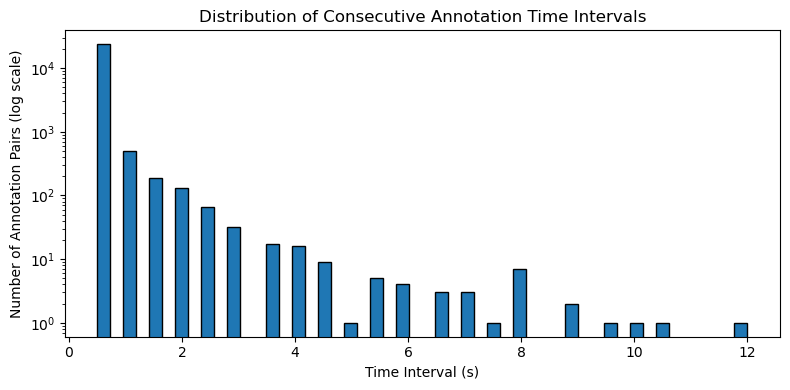

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.hist(
    annotation_pairs["dt_s"],
    bins=50,
    edgecolor="black",
)

plt.yscale("log")

plt.xlabel("Time Interval (s)")
plt.ylabel("Number of Annotation Pairs (log scale)")
plt.title("Distribution of Consecutive Annotation Time Intervals")

plt.tight_layout()
plt.show()

### Time Interval Check

All consecutive annotation pairs have positive time differences.

Most annotation intervals are concentrated around 0.5 seconds, indicating a consistent temporal spacing for the majority of object trajectories. A much smaller number of longer intervals are also present, extending to approximately 12 seconds.

The logarithmic count scale is used to make these less frequent long intervals visible. These intervals are retained at this stage and will be considered when evaluating the derived reference velocity.

## 6. Calculate Position Changes

Position changes are calculated between the start and end annotations of each consecutive annotation pair.

For each interval:

$$
\Delta x = x_{end} - x_{start}
$$

$$
\Delta y = y_{end} - y_{start}
$$

$$
\Delta z = z_{end} - z_{start}
$$

The 2D ground-plane displacement is:

$$
d_{2D} = \sqrt{(\Delta x)^2 + (\Delta y)^2}
$$

The corresponding 3D displacement is:

$$
d_{3D} = \sqrt{(\Delta x)^2 + (\Delta y)^2 + (\Delta z)^2}
$$

Both measures are retained for analysis. The 2D displacement is the primary basis for vehicle reference velocity, while the 3D displacement is used to examine the effect of vertical position changes.

In [11]:
import importlib
import src.annotation_velocity

importlib.reload(src.annotation_velocity)

from src.annotation_velocity import add_position_changes

In [12]:
annotation_pairs = add_position_changes(
    annotation_pairs
)


print(
    "Median 2D displacement (m):",
    annotation_pairs["displacement_2d"].median()
)

print(
    "Maximum 2D displacement (m):",
    annotation_pairs["displacement_2d"].max()
)

print(
    "Median 3D displacement (m):",
    annotation_pairs["displacement_3d"].median()
)

print(
    "Maximum 3D displacement (m):",
    annotation_pairs["displacement_3d"].max()
)

print(
    "Maximum absolute z change (m):",
    annotation_pairs["dz"].abs().max()
)


display(
    annotation_pairs[
        [
            "instance_token",
            "category",
            "dt_s",
            "dx",
            "dy",
            "dz",
            "displacement_2d",
            "displacement_3d",
        ]
    ].head()
)

Median 2D displacement (m): 0.2269568677297321
Maximum 2D displacement (m): 103.84766430967694
Median 3D displacement (m): 0.8027633885133236
Maximum 3D displacement (m): 103.84909589103275
Maximum absolute z change (m): 9.206354802014062


,instance_token,category,dt_s,dx,dy,dz,displacement_2d,displacement_3d
0,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.500486,0.033800,-0.064843,-0.077828,0.073123,0.106790
1,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.499633,0.003686,-0.084902,-0.013918,0.084982,0.086114
2,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.499688,0.013642,0.052521,0.170043,0.054264,0.178491
3,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.500275,-0.062382,-0.011364,0.111903,0.063409,0.128619
4,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.500131,0.104109,-0.022577,0.097924,0.106529,0.144698


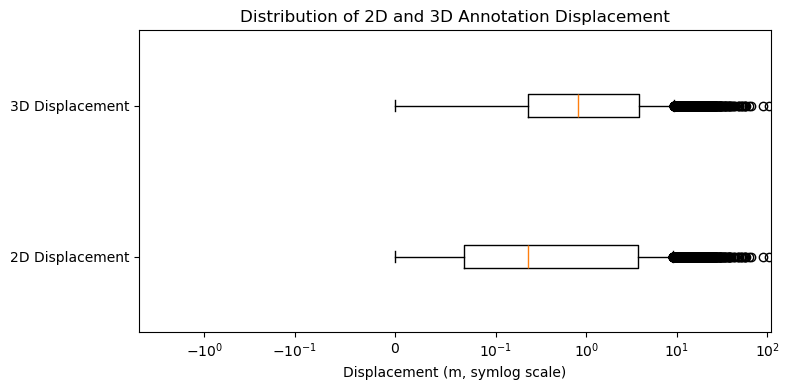

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.boxplot(
    [
        annotation_pairs["displacement_2d"],
        annotation_pairs["displacement_3d"],
    ],
    vert=False,
)

plt.yticks(
    [1, 2],
    ["2D Displacement", "3D Displacement"]
)

plt.xscale(
    "symlog",
    linthresh=0.1
)

plt.xlabel("Displacement (m, symlog scale)")
plt.title("Distribution of 2D and 3D Annotation Displacement")

plt.tight_layout()
plt.show()

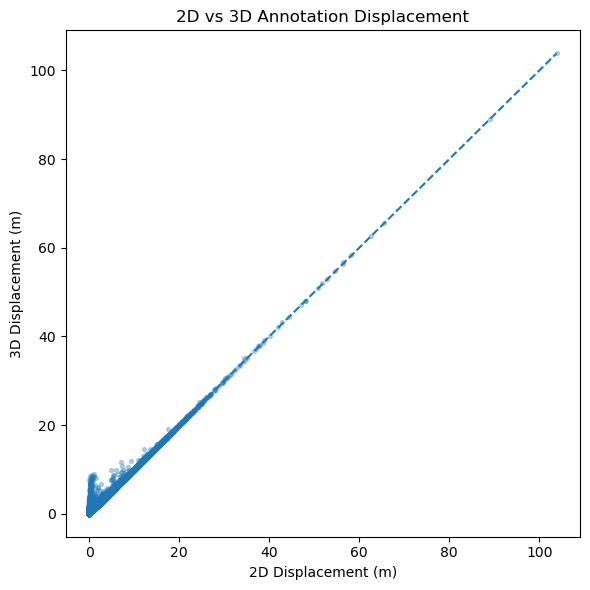

In [14]:
plt.figure(figsize=(6, 6))

plt.scatter(
    annotation_pairs["displacement_2d"],
    annotation_pairs["displacement_3d"],
    s=8,
    alpha=0.3,
)

max_displacement = max(
    annotation_pairs["displacement_2d"].max(),
    annotation_pairs["displacement_3d"].max(),
)

plt.plot(
    [0, max_displacement],
    [0, max_displacement],
    linestyle="--",
)

plt.xlabel("2D Displacement (m)")
plt.ylabel("3D Displacement (m)")
plt.title("2D vs 3D Annotation Displacement")

plt.tight_layout()
plt.show()

### Position Change Check

The median 2D displacement is approximately 0.23 m, while the median 3D displacement is approximately 0.80 m. This indicates that vertical position changes can noticeably increase the estimated displacement for many annotation intervals.

The 2D–3D scatter plot shows that larger displacements are generally close to the equality line, while greater differences between 2D and 3D displacement are more visible for some smaller ground-plane movements.

A number of large displacement values are also present. These are not removed at this stage because some annotation pairs contain longer time intervals, so a large displacement alone does not indicate an invalid trajectory.

Both 2D and 3D displacement are retained for later comparison. The 2D ground-plane displacement remains the primary basis for vehicle reference velocity, while the 3D displacement is used as a diagnostic measure.

## 7. Calculate 2D and 3D Reference Velocity

Reference velocity is calculated from the position change between consecutive annotations and the corresponding time interval.

The velocity components are:

$$
v_x = \frac{\Delta x}{\Delta t}
$$

$$
v_y = \frac{\Delta y}{\Delta t}
$$

$$
v_z = \frac{\Delta z}{\Delta t}
$$

The 2D ground-plane speed is:

$$
v_{2D} = \sqrt{v_x^2 + v_y^2}
$$

The corresponding 3D speed is:

$$
v_{3D} = \sqrt{v_x^2 + v_y^2 + v_z^2}
$$

Both 2D and 3D reference speeds are retained for analysis.

The 2D ground-plane speed is used as the primary vehicle reference for later speed grouping and RADAR–LiDAR comparison, while the 3D speed is used to evaluate the influence of vertical annotation changes.

In [15]:
import importlib
import src.annotation_velocity

importlib.reload(src.annotation_velocity)

from src.annotation_velocity import add_reference_velocity

In [16]:
velocity_df = add_reference_velocity(
    annotation_pairs
)


print(
    "Median 2D speed (m/s):",
    velocity_df["speed_2d_mps"].median()
)

print(
    "Maximum 2D speed (m/s):",
    velocity_df["speed_2d_mps"].max()
)

print(
    "Median 3D speed (m/s):",
    velocity_df["speed_3d_mps"].median()
)

print(
    "Maximum 3D speed (m/s):",
    velocity_df["speed_3d_mps"].max()
)


display(
    velocity_df[
        [
            "instance_token",
            "category",
            "dt_s",
            "vx_mps",
            "vy_mps",
            "vz_mps",
            "speed_2d_mps",
            "speed_3d_mps",
        ]
    ].head()
)

Median 2D speed (m/s): 0.42128393319542373
Maximum 2D speed (m/s): 61.54008818550941
Median 3D speed (m/s): 1.511621648419141
Maximum 3D speed (m/s): 61.54273863622901


,instance_token,category,dt_s,vx_mps,vy_mps,vz_mps,speed_2d_mps,speed_3d_mps
0,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.500486,0.067534,-0.129559,-0.155504,0.146104,0.213373
1,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.499633,0.007378,-0.169928,-0.027857,0.170088,0.172354
2,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.499688,0.027302,0.105107,0.340298,0.108595,0.357205
3,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.500275,-0.124696,-0.022715,0.223682,0.126748,0.257097
4,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.500131,0.208164,-0.045142,0.195797,0.213002,0.289321


## 8. Analyse Vehicle Reference Speed

The reference-velocity table contains multiple object categories. This section focuses on target vehicles for the later RADAR–LiDAR comparison.

Vehicle categories are identified using the `vehicle.` prefix observed in `category.json`. `vehicle.ego_trailer` is excluded because it belongs to the recording vehicle rather than an independent target object.

Both 2D and 3D annotation-derived speeds are retained and analysed.

The 2D ground-plane speed is used as the primary reference for defining comparable vehicle-speed conditions, while the 3D speed is retained to evaluate the effect of vertical annotation changes.

Extreme values are inspected before any filtering is applied.

In [17]:
vehicle_velocity_df = (
    velocity_df[
        velocity_df["category"].str.startswith("vehicle.")
        & (velocity_df["category"] != "vehicle.ego_trailer")
    ]
    .copy()
)


print(
    "Vehicle velocity intervals:",
    len(vehicle_velocity_df)
)

print(
    "Unique vehicle instances:",
    vehicle_velocity_df["instance_token"].nunique()
)

print(
    "Vehicle categories:",
    sorted(vehicle_velocity_df["category"].unique())
)

print()

print(
    "Median vehicle 2D speed (m/s):",
    vehicle_velocity_df["speed_2d_mps"].median()
)

print(
    "Median vehicle 3D speed (m/s):",
    vehicle_velocity_df["speed_3d_mps"].median()
)

print(
    "Maximum vehicle 2D speed (m/s):",
    vehicle_velocity_df["speed_2d_mps"].max()
)

print(
    "Maximum vehicle 3D speed (m/s):",
    vehicle_velocity_df["speed_3d_mps"].max()
)

Vehicle velocity intervals: 15743
Unique vehicle instances: 750
Vehicle categories: ['vehicle.bicycle', 'vehicle.bus.rigid', 'vehicle.car', 'vehicle.construction', 'vehicle.motorcycle', 'vehicle.other', 'vehicle.trailer', 'vehicle.train', 'vehicle.truck']

Median vehicle 2D speed (m/s): 4.0967816415616936
Median vehicle 3D speed (m/s): 4.321173687893897
Maximum vehicle 2D speed (m/s): 61.54008818550941
Maximum vehicle 3D speed (m/s): 61.54273863622901


In [18]:
display(
    vehicle_velocity_df[
        [
            "instance_token",
            "category",
            "start_sample_token",
            "end_sample_token",
            "dt_s",
            "dx",
            "dy",
            "dz",
            "speed_2d_mps",
            "speed_3d_mps",
        ]
    ]
    .sort_values(
        "speed_2d_mps",
        ascending=False,
    )
    .head(10)
)

,instance_token,category,start_sample_token,end_sample_token,dt_s,dx,dy,dz,speed_2d_mps,speed_3d_mps
7071,7051458dfbe44f409e9adae652a76de4,vehicle.truck,e527f6f066f143d68f20aadb009db2a7,ad8c44a11384426e915df188732b1a80,0.499447,30.278163,-5.285388,-0.285265,61.540088,61.542739
2204,c5bfd518808141c193e806abccc99f70,vehicle.car,80ad351eb99e4b28bfbec1105b6ac8eb,85c5ca01cfb34d3e92d1c0c265235d04,0.500715,11.464996,-22.329428,0.128187,50.129887,50.130541
2205,c5bfd518808141c193e806abccc99f70,vehicle.car,85c5ca01cfb34d3e92d1c0c265235d04,68d8f0410d4342a1a6d2687b0deeb24c,0.500286,11.812942,-21.836849,-1.015910,49.626164,49.667693
1880,7c987764126149ba85594c712f65307a,vehicle.truck,9bd4a2d0f3ae4c5fbc8f9b25c3a5fc05,0556486618ae429895ef8caa898ee953,0.500125,-10.864893,21.932583,1.673160,48.940155,49.054368
1936,898a1d15a70f4500b79796d44cd7344e,vehicle.car,51c116a371d645668dac1af0a02ee674,7a7c5575a7c342619ce96378e04038a1,0.500344,10.478872,-20.856782,-1.226220,46.650326,46.714657
1419,324104d35aef4bf9b33b00be3717e0d2,vehicle.car,34d0b00f1801498c803ec07dce543b72,8087e38a235948e1a12fc698a2fbd73d,0.500298,10.332974,-20.828253,-0.712839,46.473333,46.495170
7213,8992413f4e07400096f6b7ff4eda7e21,vehicle.trailer,e527f6f066f143d68f20aadb009db2a7,ad8c44a11384426e915df188732b1a80,0.499447,-22.882794,3.676435,0.008672,46.403818,46.403821
1935,898a1d15a70f4500b79796d44cd7344e,vehicle.car,6f61d7af183f4094919330d51465c1aa,51c116a371d645668dac1af0a02ee674,0.500658,10.637138,-20.505736,-0.603999,46.140315,46.156084
1934,898a1d15a70f4500b79796d44cd7344e,vehicle.car,65f73fc2d0c343fc8e5018c4f42219c6,6f61d7af183f4094919330d51465c1aa,0.500108,10.444935,-20.467301,-0.858048,45.946884,45.978907
1929,898a1d15a70f4500b79796d44cd7344e,vehicle.car,2e9658149ff64abe863691ca1ab21659,25d2fdbc5fab4e93b80c4064eb60fa38,0.500075,10.317976,-20.319960,-0.554756,45.572168,45.585668


### Vehicle Reference Speed Distribution

The distribution of 2D vehicle reference speed shows the range of target-vehicle motion available in the current TruckScenes dataset.

A logarithmic count scale is used so that both the dominant speed region and less frequent high-speed observations remain visible.

This distribution will be used to define the speed ranges for the later RADAR and LiDAR comparison.

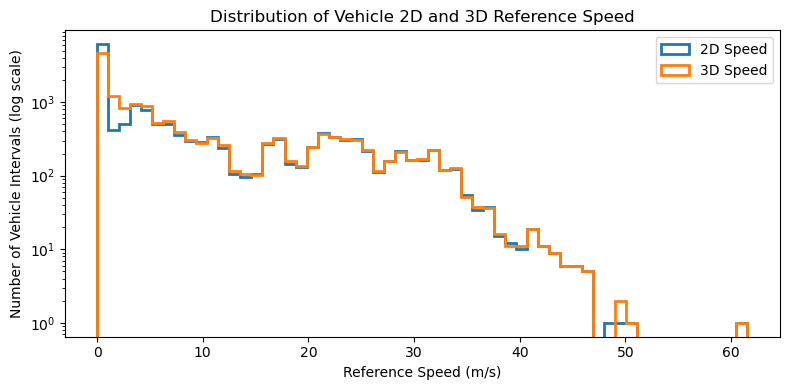

In [19]:
import numpy as np
import matplotlib.pyplot as plt


bins = np.linspace(
    0,
    max(
        vehicle_velocity_df["speed_2d_mps"].max(),
        vehicle_velocity_df["speed_3d_mps"].max(),
    ),
    60,
)

plt.figure(figsize=(8, 4))

plt.hist(
    vehicle_velocity_df["speed_2d_mps"],
    bins=bins,
    histtype="step",
    linewidth=2,
    label="2D Speed",
)

plt.hist(
    vehicle_velocity_df["speed_3d_mps"],
    bins=bins,
    histtype="step",
    linewidth=2,
    label="3D Speed",
)

plt.yscale("log")

plt.xlabel("Reference Speed (m/s)")
plt.ylabel("Number of Vehicle Intervals (log scale)")
plt.title("Distribution of Vehicle 2D and 3D Reference Speed")
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
speed_summary = (
    vehicle_velocity_df[
        [
            "speed_2d_mps",
            "speed_3d_mps",
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

display(speed_summary)

,speed_2d_mps,speed_3d_mps
count,15743.000000,15743.000000
mean,8.838305,9.146880
std,10.592799,10.437434
min,0.000000,0.000000
25%,0.232275,0.690739
50%,4.096782,4.321174
75%,16.571971,16.678856
90%,25.731253,25.771783
95%,30.738668,30.778663
99%,35.699317,35.727601


### Vehicle Speed Check

The vehicle subset contains 15,743 reference-velocity intervals from 750 unique target-vehicle instances.

The median 2D reference speed is approximately 4.10 m/s, while the median 3D reference speed is approximately 4.32 m/s. The two distributions are therefore broadly similar for vehicle targets, although the 3D speed is slightly higher because it also includes vertical motion.

The maximum 2D and 3D speeds are almost identical at approximately 61.54 m/s. This indicates that the highest-speed observations are dominated by ground-plane motion rather than changes in the vertical position.

Overall, the 2D and 3D reference speeds agree more closely for vehicles than for the full set of annotated objects. The 2D ground-plane speed is therefore retained as the primary reference measure for defining comparable vehicle-speed conditions, while the 3D speed is kept as a diagnostic measure for monitoring the influence of vertical annotation changes.

## 9. Define WA-Aligned Vehicle Speed Ranges

Comparable target-vehicle speed conditions are required for the later RADAR and LiDAR analyses.

Rather than defining arbitrary low-, medium-, and high-speed groups, the speed-range boundaries are aligned with the legal speed-limit increments used in Western Australia.

Western Australian road speed limits include 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, and 110 km/h. The default limit in built-up areas is 50 km/h, while the maximum default limit for rural or undeveloped areas is 110 km/h.

These legal speed values are used only as practical and interpretable boundaries for grouping the observed vehicle reference speeds. They do not indicate the actual posted speed limit of the road on which each TruckScenes vehicle was travelling.

The 2D ground-plane reference speed is used for speed-range assignment. The 3D reference speed remains available as a diagnostic measure.

In [21]:
vehicle_velocity_df["speed_2d_kmh"] = (
    vehicle_velocity_df["speed_2d_mps"] * 3.6
)

vehicle_velocity_df["speed_3d_kmh"] = (
    vehicle_velocity_df["speed_3d_mps"] * 3.6
)


speed_bins_kmh = [
    0,
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100,
    110,
    float("inf"),
]

speed_labels = [
    "0–<10",
    "10–<20",
    "20–<30",
    "30–<40",
    "40–<50",
    "50–<60",
    "60–<70",
    "70–<80",
    "80–<90",
    "90–<100",
    "100–<110",
    "≥110",
]


vehicle_velocity_df["speed_range_kmh"] = pd.cut(
    vehicle_velocity_df["speed_2d_kmh"],
    bins=speed_bins_kmh,
    labels=speed_labels,
    right=False,
    include_lowest=True,
)

In [22]:
speed_range_summary = (
    vehicle_velocity_df
    .groupby(
        "speed_range_kmh",
        observed=False,
    )
    .agg(
        velocity_intervals=(
            "speed_2d_kmh",
            "count",
        ),
        unique_instances=(
            "instance_token",
            "nunique",
        ),
    )
)

speed_range_summary["interval_percentage"] = (
    speed_range_summary["velocity_intervals"]
    / len(vehicle_velocity_df)
    * 100
)

display(
    speed_range_summary.round(2)
)

,velocity_intervals,unique_instances,interval_percentage
speed_range_kmh,,,
0–<10,6870,361,43.64
10–<20,2028,181,12.88
20–<30,1211,150,7.69
30–<40,799,129,5.08
40–<50,510,94,3.24
50–<60,424,73,2.69
60–<70,542,69,3.44
70–<80,823,86,5.23
80–<90,797,108,5.06


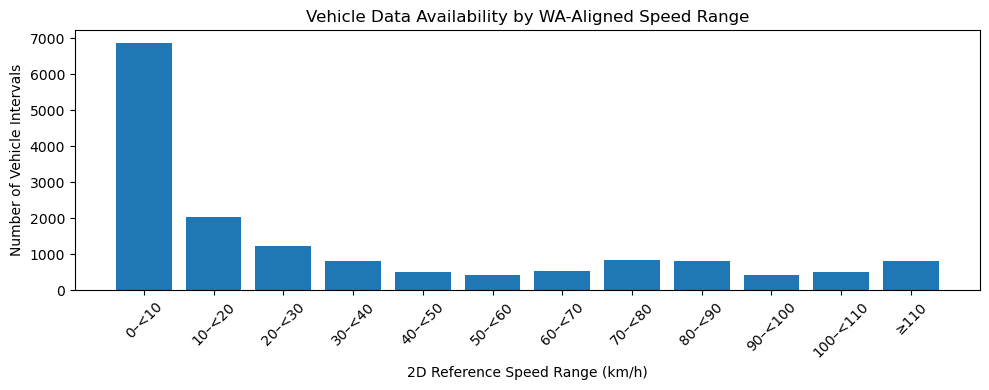

In [23]:
plt.figure(figsize=(10, 4))

plt.bar(
    speed_range_summary.index.astype(str),
    speed_range_summary["velocity_intervals"],
)

plt.xlabel("2D Reference Speed Range (km/h)")
plt.ylabel("Number of Vehicle Intervals")
plt.title("Vehicle Data Availability by WA-Aligned Speed Range")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Speed Range Check

The WA-aligned speed ranges provide substantially more detailed comparison conditions than broad low-, medium-, and high-speed categories.

The largest proportion of vehicle reference-velocity intervals falls below 10 km/h, accounting for approximately 43.64% of the available intervals. The remaining observations are distributed across the 10 km/h speed ranges up to and beyond 110 km/h.

All defined speed ranges contain several hundred velocity intervals, and each range is represented by at least 66 unique vehicle instances. Therefore, no adjacent speed ranges are merged at this stage.

The speed boundaries follow the regulatory speed-limit increments used in Western Australia and are used only as interpretable analytical reference ranges. They do not represent the actual posted speed limits of the TruckScenes recording locations.

The 2D ground-plane reference speed is used to assign each interval to a speed range. The corresponding 3D reference speed remains available as a diagnostic measure for later analysis.

## 10. Summary and Limitations

This notebook established an annotation-derived reference-velocity workflow for tracked objects in TruckScenes.

The workflow linked 25,750 annotations across 1,094 object instances and constructed 24,656 consecutive annotation pairs using the annotation `next` relationships. No missing sample timestamps, invalid annotation links, or non-positive time differences were identified.

Most consecutive annotations are separated by approximately 0.5 seconds, although a small number of longer annotation gaps are present, extending to approximately 12 seconds. These longer intervals were retained rather than automatically removed.

Both 2D and 3D displacement and reference velocity were calculated. The comparison showed that vertical annotation changes can noticeably increase the 3D motion estimate, particularly for observations with relatively small ground-plane motion. Therefore, the 2D ground-plane speed is used as the primary vehicle reference velocity, while the 3D speed is retained as a diagnostic measure.

After excluding `vehicle.ego_trailer`, the vehicle subset contains 15,743 reference-velocity intervals from 750 unique target-vehicle instances. The median vehicle reference speed is approximately 4.10 m/s using the 2D measure and 4.32 m/s using the 3D measure.

For later RADAR and LiDAR comparison, the 2D vehicle reference speed is also represented in km/h and grouped using 10 km/h boundaries aligned with the speed-limit increments used in Western Australia. These ranges are used only as interpretable analytical speed conditions and do not represent the actual posted speed limits of the TruckScenes recording locations.

All defined speed ranges contain several hundred velocity intervals and at least 66 unique vehicle instances, so the ranges are retained without further merging.

### Limitations

- The derived velocity represents average object motion between consecutive annotation keyframes rather than an instantaneous ground-truth velocity measurement.
- Some annotation trajectories contain longer time gaps, which may reduce the temporal precision of the corresponding velocity estimates.
- Vertical annotation changes can substantially affect 3D velocity, so 3D speed is not used as the primary vehicle-speed measure.
- The current vehicle subset includes multiple vehicle types. Vehicle-category composition may need to be considered when interpreting later sensor comparisons.
- The WA-aligned speed ranges provide consistent analytical boundaries only; they do not imply that TruckScenes vehicles were travelling on roads with those posted speed limits.
- Extreme reference-speed observations are retained at this stage and should be considered when interpreting later RADAR and LiDAR results.

The resulting vehicle reference-velocity table and speed ranges provide the common motion reference required for the subsequent RADAR, LiDAR, and sensor-comparison notebooks.

In [24]:
from pathlib import Path

RESULTS_ROOT = Path("../results/validated")

vehicle_velocity_df.to_pickle(
    RESULTS_ROOT / "vehicle_reference_df.pkl"
)

print("Saved vehicle_reference_df.pkl")
print("Rows:", len(vehicle_velocity_df))

Saved vehicle_reference_df.pkl
Rows: 15743
